# 07 — Final Model Selection & Interpretation

This notebook fixes the **final model, feature set and alert threshold** from cross-validation on the *training* split alone, interprets the result, evaluates it **once** on the held-out test split, and saves the artifact the backend loads (`models/final_pipeline.joblib`).

Order of work, and what each step rests on:

| Section | Question | Evidence used |
| --- | --- | --- |
| 1 | Which model? | the four tuned models from notebook 06, recomputed here |
| 2–3 | Do the engineered features help, and can the API supply them? | feature ablation, serving-skew test, train/serve parity |
| 4 | Do temperatures and `grip_lost` earn their place? | importance, time-forward validation, temperature-vs-time checks |
| 5–6 | Final model, and what it relies on | SHAP, out-of-fold permutation importance |
| 7 | Where should the alert threshold sit? | out-of-fold predictions, event-level metrics |
| 8 | How does it do on unseen, later cycles? | the one-shot test evaluation |
| 9 | Save | reload check |

Everything before section 8 uses **train only**. The test split is not read until section 8, after every choice has been fixed.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from scipy.stats import randint, spearmanr, uniform
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from src.config import RANDOM_STATE, MODELS_DIR, FIGURES_DIR, PROCESSED_DATA_DIR
from src.evaluate import episode_metrics, evaluate_cv, find_runs
from src.features import CURRENT_COLS, LAG_ROWS, WINDOW_ROWS, add_engineered_features
from src.pipeline import build_preprocessing_pipeline

# joblib/loky can't count physical cores on Windows machines without `wmic`; harmless and unrelated to results.
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

## Load the training split

Only the **train** split is loaded here. The held-out test split is not touched until the one-shot evaluation in section 8.

In [3]:
train_df = pd.read_parquet(PROCESSED_DATA_DIR / "train.parquet")

with open(PROCESSED_DATA_DIR / "eligible_features.json") as f:
    ALL_FEATURES = json.load(f)

BINARY_COLS = ["grip_lost"]
ENGINEERED = ["total_joint_current", "total_joint_current_delta3"]

X_train = train_df[ALL_FEATURES]
y_train = train_df["Robot_ProtectiveStop"]
groups = train_df["cycle"]

# Same fold configuration as notebooks 05 and 06.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Best hyperparameters from notebook 06 (these are inputs; every CV number below is recomputed live).
TUNED_PARAMS = {
    "Logistic Regression": {"C": 0.04994877024461302, "class_weight": None, "penalty": "l2"},
    "XGBoost": {"learning_rate": 0.04540550686319527, "max_depth": 3, "n_estimators": 330,
                "scale_pos_weight": 28.204853246372622},
    "Random Forest": {"class_weight": "balanced_subsample", "max_depth": 15,
                      "min_samples_leaf": 7, "n_estimators": 286},
    "SVM (RBF)": {"C": 8.241925264876453, "class_weight": "balanced", "gamma": 0.02653627132902631},
}


def make_pipeline(name, features, params=None):
    """Preprocessing + classifier for `features`; `params` defaults to the notebook-06 tuned values."""
    binary = [c for c in features if c in BINARY_COLS]
    continuous = [c for c in features if c not in BINARY_COLS]
    prep = build_preprocessing_pipeline(continuous, binary)
    p = dict(TUNED_PARAMS[name] if params is None else params)
    if name == "Logistic Regression":
        clf = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="liblinear", **p)
    elif name == "XGBoost":
        clf = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="aucpr", **p)
    elif name == "Random Forest":
        clf = RandomForestClassifier(random_state=RANDOM_STATE, **p)
    elif name == "SVM (RBF)":
        clf = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, **p)
    else:
        raise ValueError(name)
    return Pipeline([("preprocessing", prep), ("classifier", clf)])


X_train.shape, round(float(y_train.mean()), 4)

((5468, 16), 0.0311)

## 1. Model comparison: the four tuned models, side by side

The plan says to weigh PR-AUC, **fold stability**, **interpretability** and **inference speed**, not PR-AUC alone. The CV numbers are recomputed here from the notebook-06 hyperparameters (they should reproduce notebook 06 exactly), and per-fold PR-AUC is shown so the size of any gap can be judged against fold-to-fold noise rather than read off the means. All models here use the same 16 features notebook 06 tuned on; section 4 repeats the ranking on the final, smaller feature set.

In [4]:
rows, folds = [], {}
for name in TUNED_PARAMS:
    s = evaluate_cv(make_pipeline(name, ALL_FEATURES), X_train, y_train, groups, return_folds=True)
    folds[name] = s.pop("folds")
    rows.append({"model": name, **s})

comparison = pd.DataFrame(rows).set_index("model")
comparison[["pr_auc_mean", "pr_auc_std", "recall_mean", "recall_std",
            "precision_mean", "f1_mean", "roc_auc_mean"]].round(3)

,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,f1_mean,roc_auc_mean
model,,,,,,,
Logistic Regression,0.165,0.023,0.000,0.000,0.000,0.000,0.766
XGBoost,0.473,0.074,0.689,0.159,0.441,0.513,0.924
Random Forest,0.439,0.111,0.499,0.159,0.413,0.432,0.938
SVM (RBF),0.388,0.063,0.736,0.140,0.238,0.354,0.875


In [5]:
fold_pr = pd.DataFrame({n: folds[n]["pr_auc"] for n in folds}).T
fold_pr.columns = [f"fold{i + 1}" for i in range(fold_pr.shape[1])]
print("Per-fold PR-AUC:")
print(fold_pr.round(3).to_string())

xgb_folds = np.array(folds["XGBoost"]["pr_auc"])
print()
for n in folds:
    if n != "XGBoost":
        other = np.array(folds[n]["pr_auc"])
        print(f"XGBoost ahead of {n:20s} in {(xgb_folds > other).sum()}/5 folds "
              f"(mean gap {np.mean(xgb_folds - other):+.3f})")

Per-fold PR-AUC:
                     fold1  fold2  fold3  fold4  fold5
Logistic Regression  0.159  0.185  0.156  0.194  0.130
XGBoost              0.429  0.471  0.461  0.611  0.393
Random Forest        0.409  0.425  0.294  0.636  0.429
SVM (RBF)            0.385  0.351  0.306  0.493  0.407

XGBoost ahead of Logistic Regression  in 5/5 folds (mean gap +0.309)
XGBoost ahead of Random Forest        in 3/5 folds (mean gap +0.035)
XGBoost ahead of SVM (RBF)            in 4/5 folds (mean gap +0.085)


In [6]:
def single_row_latency_ms(name, n=200):
    """Median / p95 latency of one predict_proba call on a single-row DataFrame (what the API does)."""
    pipe = make_pipeline(name, ALL_FEATURES).fit(X_train, y_train)
    idx = np.random.default_rng(RANDOM_STATE).choice(len(X_train), size=n, replace=False)
    times = []
    for i in idx:
        row = X_train.iloc[[i]]
        t0 = time.perf_counter()
        pipe.predict_proba(row)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.median(times)), float(np.percentile(times, 95))


latency = pd.DataFrame(
    {name: single_row_latency_ms(name) for name in TUNED_PARAMS}, index=["median_ms", "p95_ms"]
).T
latency.round(2)

,median_ms,p95_ms
Logistic Regression,6.47,7.70
XGBoost,6.30,7.85
Random Forest,16.77,27.51
SVM (RBF),6.07,8.99


### Comparing the models at matched operating points

Recall, precision and F1 above are measured at the default 0.5 threshold, which is unfair to models whose probabilities are compressed (Random Forest, Logistic Regression): their recall looks low only because 0.5 is the wrong cut-off for them. Here each model's out-of-fold probabilities are compared threshold-free: the best F1 reachable at any threshold, and the **precision available at a fixed recall**. If a model needs a lower threshold to reach the same recall, this shows what that costs.

In [7]:
def oof_proba(name):
    return cross_val_predict(make_pipeline(name, ALL_FEATURES), X_train, y_train,
                             groups=groups, cv=cv, method="predict_proba")[:, 1]


def operating_summary(p):
    prec, rec, _ = precision_recall_curve(y_train, p)
    prec, rec = prec[:-1], rec[:-1]
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    out = {"pooled PR-AUC": average_precision_score(y_train, p), "best F1": f1.max()}
    for target in (0.70, 0.80, 0.90):
        ok = rec >= target
        out[f"precision @ recall>={target:.2f}"] = prec[ok].max() if ok.any() else np.nan
    return out


oof_all = {name: oof_proba(name) for name in TUNED_PARAMS}
operating = pd.DataFrame({name: operating_summary(p) for name, p in oof_all.items()}).T
operating.round(3)

,pooled PR-AUC,best F1,precision @ recall>=0.70,precision @ recall>=0.80,precision @ recall>=0.90
Logistic Regression,0.134,0.239,0.072,0.054,0.036
XGBoost,0.432,0.519,0.410,0.325,0.109
Random Forest,0.391,0.502,0.377,0.322,0.147
SVM (RBF),0.348,0.444,0.258,0.166,0.051


## 2. Feature ablation: do the engineered features earn their place?

Three feature sets, each with XGBoost **re-tuned on that set** using the same search space, seed and folds as notebook 06 (so a set is not penalised for hyperparameters tuned for a different one):

| Set | Features |
| --- | --- |
| 16 | 14 raw eligible features + `total_joint_current` + `total_joint_current_delta3` |
| 15 | as above without `total_joint_current_delta3` |
| 14 | raw eligible features only |

`total_joint_current` can be computed from a single reading. `total_joint_current_delta3` **cannot**: it is the change over the previous 3 readings of the same cycle, so it needs history. The API originally took one reading per request, so at serving time that feature would be missing and the imputer would fill the training median. The last cell of this section measures what that costs.

In [8]:
XGB_SPACE = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": randint(3, 10),
    "classifier__learning_rate": uniform(0.01, 0.29),
    "classifier__scale_pos_weight": uniform(1, 30),
}

FEATURE_SETS = {
    "16": ALL_FEATURES,
    "15": [f for f in ALL_FEATURES if f != "total_joint_current_delta3"],
    "14": [f for f in ALL_FEATURES if f not in ENGINEERED],
}


def tune_xgb(features):
    search = RandomizedSearchCV(
        make_pipeline("XGBoost", features, params={}), XGB_SPACE, n_iter=40,
        scoring="average_precision", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train[features], y_train, groups=groups)
    best = {k.replace("classifier__", ""): v for k, v in search.best_params_.items()}
    scores = evaluate_cv(make_pipeline("XGBoost", features, params=best),
                         X_train[features], y_train, groups, return_folds=True)
    return best, scores


ablation = {}
for label, feats in FEATURE_SETS.items():
    best, scores = tune_xgb(feats)
    ablation[label] = {"features": feats, "params": best, "folds": scores.pop("folds"), "scores": scores}

ablation_table = pd.DataFrame({k: v["scores"] for k, v in ablation.items()}).T
print(ablation_table[["pr_auc_mean", "pr_auc_std", "recall_mean", "precision_mean", "f1_mean"]].round(3).to_string())

base16 = np.array(ablation["16"]["folds"]["pr_auc"])
print()
for k in ("15", "14"):
    other = np.array(ablation[k]["folds"]["pr_auc"])
    print(f"{k}-feature set vs 16: PR-AUC delta {other.mean() - base16.mean():+.3f}, "
          f"ahead of 16 in {(other > base16).sum()}/5 folds")
print()
print("Re-tuned params for the 16-feature set (should equal notebook 06):", ablation["16"]["params"])

    pr_auc_mean  pr_auc_std  recall_mean  precision_mean  f1_mean
16        0.473       0.074        0.689           0.441    0.513
15        0.414       0.046        0.692           0.394    0.477
14        0.416       0.060        0.683           0.363    0.453

15-feature set vs 16: PR-AUC delta -0.060, ahead of 16 in 0/5 folds
14-feature set vs 16: PR-AUC delta -0.058, ahead of 16 in 1/5 folds

Re-tuned params for the 16-feature set (should equal notebook 06): {'learning_rate': 0.04540550686319527, 'max_depth': 3, 'n_estimators': 330, 'scale_pos_weight': 28.204853246372622}


In [9]:
def drop_history(X):
    """What a single-reading API would do: delta3 needs history it does not have, so it is missing."""
    X = X.copy()
    X["total_joint_current_delta3"] = np.nan
    return X


served = evaluate_cv(
    make_pipeline("XGBoost", ALL_FEATURES, params=ablation["16"]["params"]),
    X_train, y_train, groups, return_folds=True, val_transform=drop_history,
)
served_folds = served.pop("folds")

skew = pd.DataFrame({
    "16 features, with history (as evaluated)": ablation["16"]["scores"],
    "16 features, served WITHOUT history": served,
    "15 features (trained and served alike)": ablation["15"]["scores"],
}).T
print(skew[["pr_auc_mean", "pr_auc_std", "recall_mean", "precision_mean", "f1_mean"]].round(3).to_string())

                                          pr_auc_mean  pr_auc_std  recall_mean  precision_mean  f1_mean
16 features, with history (as evaluated)        0.473       0.074        0.689           0.441    0.513
16 features, served WITHOUT history             0.379       0.064        0.528           0.427    0.438
15 features (trained and served alike)          0.414       0.046        0.692           0.394    0.477


## 3. Decision: input design

The serving-skew result above settles it. Serving a model trained with `total_joint_current_delta3` **without** history loses about 0.09 PR-AUC (0.473 to 0.379) and a third of its recall (0.689 to 0.528), which is worse than not using the feature at all (0.414). The same feature *with* history is worth about +0.06 PR-AUC (0.473 vs 0.414, ahead in 5 of 5 folds). Only two designs make sense:

- one reading per request, without the trend feature, or
- **a reading plus history per request, keeping the trend feature (chosen).**

`delta3` is `total_joint_current` now minus `total_joint_current` `LAG_ROWS` = 3 readings earlier, so the API needs the current reading and the reading 3 steps back (`WINDOW_ROWS` = 4 consecutive readings if sent as a window; the two in between are not used). The API computes it with the same code as training (`src/features.py`), so there is no train/serve skew. Assumptions the API cannot verify: the readings are consecutive and from the same cycle.

In [10]:
# Train/serve parity: the shared feature code must reproduce the stored training features exactly.
raw = train_df.drop(columns=ENGINEERED)

rebuilt = add_engineered_features(raw, group_col="cycle")
for col in ENGINEERED:
    np.testing.assert_allclose(rebuilt[col].to_numpy(), train_df[col].to_numpy(), equal_nan=True)
print("Whole train split: src.features reproduces both stored engineered columns exactly.")

# The serving path: a bare 4-row window (no cycle column) through the same function must give the
# same delta3 the model saw in training for that row.
cyc = train_df["cycle"].to_numpy()
full_windows = [i for i in range(WINDOW_ROWS - 1, len(train_df))
                if len(set(cyc[i - WINDOW_ROWS + 1: i + 1])) == 1]
sample = np.random.default_rng(RANDOM_STATE).choice(full_windows, size=300, replace=False)
served_delta3 = [
    add_engineered_features(raw.iloc[i - WINDOW_ROWS + 1: i + 1]).iloc[-1]["total_joint_current_delta3"]
    for i in sample
]
np.testing.assert_allclose(served_delta3, train_df["total_joint_current_delta3"].iloc[sample].to_numpy())
print(f"Serving path: 300 random {WINDOW_ROWS}-row windows give the same delta3 as training.")

Whole train split: src.features reproduces both stored engineered columns exactly.


Serving path: 300 random 4-row windows give the same delta3 as training.


## 4. Do temperatures and `grip_lost` earn their place?

Out-of-fold permutation importance on the 16-feature model is the trigger: it says the six temperatures and `grip_lost` contribute almost nothing. That matters for the operator (each reading is 14 fields, and the API now needs history), and it raises a modelling question, because overheating can cause protective stops on real robots. So this section asks the question properly, on **train only**, in four steps: (a) the importance evidence, (b) what temperature actually looks like in this data, (c) whether dropping the features costs accuracy, including on *later* cycles, and (d) whether the model ranking still holds on the reduced set.

In [11]:
def oof_permutation_importance(pipe, features):
    """Permutation importance (drop in PR-AUC) computed on each validation fold of a model fit on its training folds."""
    rows = []
    for tr, va in cv.split(X_train, y_train, groups):
        fold = clone(pipe).fit(X_train[features].iloc[tr], y_train.iloc[tr])
        r = permutation_importance(fold, X_train[features].iloc[va], y_train.iloc[va],
                                   scoring="average_precision", n_repeats=10,
                                   random_state=RANDOM_STATE, n_jobs=-1)
        rows.append(r.importances_mean)
    return pd.Series(np.mean(rows, axis=0), index=features).sort_values(ascending=False)


perm_16 = oof_permutation_importance(make_pipeline("XGBoost", ALL_FEATURES), ALL_FEATURES)
print("Permutation importance, 16-feature model (drop in PR-AUC when the feature is shuffled):")
perm_16.round(4)

Permutation importance, 16-feature model (drop in PR-AUC when the feature is shuffled):


Current_J2                    0.2507
Current_J5                    0.2481
Current_J3                    0.1664
Tool_current                  0.1302
total_joint_current_delta3    0.1176
total_joint_current           0.0204
Current_J0                    0.0181
Current_J1                    0.0164
Temperature_J4                0.0069
Temperature_J3                0.0003
Temperature_J2                0.0001
Current_J4                    0.0001
grip_lost                     0.0000
Temperature_T0               -0.0003
Temperature_J1               -0.0036
Temperature_J5               -0.0125
dtype: float64

### 4b. What temperature looks like in this data

Two checks. First, how temperature relates to the clock. Second, whether stop rows are hotter than normal rows **at the same time of day**. If overheating were driving these stops, stop rows would be clearly hotter than their normal neighbours. The recording has one long break (about 5 hours) that splits it into a morning and an afternoon period; the comparison is made inside each period so that the steady warm-up cannot masquerade as a difference.

Train covers 08:17 to 15:03 on one day, one robot.

                min (C)  max (C)  Spearman corr with elapsed time
Temperature_T0    27.81    37.12                             1.00
Temperature_J1    29.31    40.12                             1.00
Temperature_J2    29.38    40.50                             0.99
Temperature_J3    32.12    43.19                             0.95
Temperature_J4    32.25    45.31                             0.84
Temperature_J5    32.00    44.94                             0.79

Median temperature at stop rows minus normal rows, inside each period (C):
                                           Temperature_T0  Temperature_J1  Temperature_J2  Temperature_J3  Temperature_J4  Temperature_J5
morning (before the break), 75 stop rows             0.88             1.0            1.06            0.88            1.06            1.19
afternoon (after the break), 95 stop rows            0.00             0.0            0.00            0.00            0.00            0

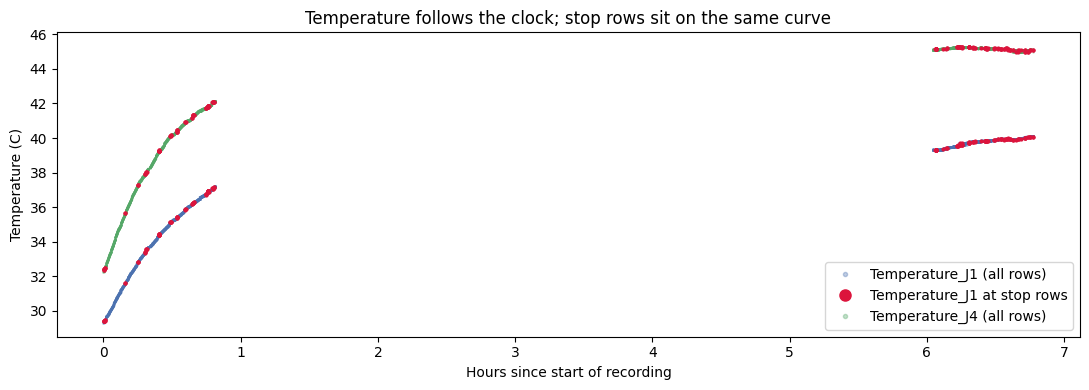

In [12]:
temp_cols = [c for c in ALL_FEATURES if c.startswith("Temperature_")]
elapsed_s = (train_df["Timestamp"] - train_df["Timestamp"].min()).dt.total_seconds()

print(f"Train covers {train_df['Timestamp'].min():%H:%M} to {train_df['Timestamp'].max():%H:%M} on one day, one robot.\n")
overview = pd.DataFrame({
    "min (C)": train_df[temp_cols].min(),
    "max (C)": train_df[temp_cols].max(),
    "Spearman corr with elapsed time": train_df[temp_cols].corrwith(elapsed_s, method="spearman"),
})
print(overview.round(2).to_string())

# Compare stop vs normal rows within each period (the long recording break separates them).
break_at = train_df["Timestamp"].diff().dt.total_seconds().idxmax()
period = np.where(train_df.index < break_at, "morning (before the break)", "afternoon (after the break)")
is_stop = (y_train == 1).to_numpy()

diff_rows = {}
for per in ("morning (before the break)", "afternoon (after the break)"):
    m = period == per
    stop_med = train_df.loc[m & is_stop, temp_cols].median()
    normal_med = train_df.loc[m & ~is_stop, temp_cols].median()
    diff_rows[f"{per}, {int((m & is_stop).sum())} stop rows"] = stop_med - normal_med
print("\nMedian temperature at stop rows minus normal rows, inside each period (C):")
print(pd.DataFrame(diff_rows).T.round(2).to_string())

# Picture: temperature is a clock; stop rows sit on the same curve as everything else.
fig, ax = plt.subplots(figsize=(11, 4))
hours = elapsed_s / 3600
for col, colour in (("Temperature_J1", "#4c72b0"), ("Temperature_J4", "#55a868")):
    ax.plot(hours, train_df[col], ".", ms=1.5, color=colour, alpha=0.35, label=f"{col} (all rows)")
    ax.plot(hours[is_stop], train_df.loc[is_stop, col], ".", ms=4, color="crimson",
            label=f"{col} at stop rows" if col == "Temperature_J1" else None)
ax.set_xlabel("Hours since start of recording")
ax.set_ylabel("Temperature (C)")
ax.set_title("Temperature follows the clock; stop rows sit on the same curve")
ax.legend(loc="lower right", markerscale=4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig07_temperature_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

### 4c. Does dropping them cost accuracy?

Three feature sets, XGBoost with the notebook-06 hyperparameters held fixed so only the features change, scored two ways:

1. **Grouped 5-fold CV** (the validation used everywhere else in the project).
2. **Time-forward validation**: cycles are ordered by start time and cut into 5 blocks; the model is trained on blocks `1..k` and scored on block `k+1` (4 folds). This asks whether the model generalises to *later* cycles, which is what the chronological test set will ask. It also catches any feature acting as a proxy for time of day, which random grouped folds cannot see.

Time-forward folds are noisier (they train on far less data and the blocks hold different numbers of stops), so read them for direction, not decimals.

In [13]:
GROUPS = {
    "all 16": ALL_FEATURES,
    "no temperatures (10)": [f for f in ALL_FEATURES if not f.startswith("Temperature_")],
    "no temperatures, no grip_lost (9)": [f for f in ALL_FEATURES
                                          if not f.startswith("Temperature_") and f != "grip_lost"],
}

cycle_order = train_df.groupby("cycle")["Timestamp"].min().sort_values().index.to_numpy()
time_blocks = np.array_split(cycle_order, 5)


def forward_chain(features, name="XGBoost"):
    """PR-AUC on each later block after training on all earlier blocks; also the stops in each block."""
    scores, stops = [], []
    for k in range(1, len(time_blocks)):
        tr = train_df["cycle"].isin(np.concatenate(time_blocks[:k])).to_numpy()
        va = train_df["cycle"].isin(time_blocks[k]).to_numpy()
        m = make_pipeline(name, features).fit(X_train.loc[tr, features], y_train[tr])
        scores.append(average_precision_score(y_train[va], m.predict_proba(X_train.loc[va, features])[:, 1]))
        stops.append(int(y_train[va].sum()))
    return scores, stops


rows = {}
for label, feats in GROUPS.items():
    g = evaluate_cv(make_pipeline("XGBoost", feats), X_train[feats], y_train, groups, return_folds=True)
    fc, stops = forward_chain(feats)
    rows[label] = {
        "grouped-CV PR-AUC": g["pr_auc_mean"], "grouped-CV std": g["pr_auc_std"],
        **{f"fwd block {k + 2}": s for k, s in enumerate(fc)}, "fwd mean": float(np.mean(fc)),
    }

print("Stop rows in each forward-validation block:", stops)
pd.DataFrame(rows).T.round(3)

Stop rows in each forward-validation block: [31, 47, 40, 39]


,grouped-CV PR-AUC,grouped-CV std,fwd block 2,fwd block 3,fwd block 4,fwd block 5,fwd mean
all 16,0.473,0.074,0.138,0.353,0.445,0.453,0.347
no temperatures (10),0.471,0.047,0.193,0.376,0.501,0.469,0.385
"no temperatures, no grip_lost (9)",0.476,0.041,0.193,0.376,0.501,0.469,0.385


### 4d. Does the model ranking hold on the reduced feature set?

The model choice in section 1 was made on 16 features. If the ranking flipped on the 9-feature set, choosing a model from the 16-feature evidence would be unsound, so it is checked here, with the same fixed hyperparameters for every model (equal treatment), under both validation schemes.

In [14]:
NINE = GROUPS["no temperatures, no grip_lost (9)"]

rank_rows, rank_folds = {}, {}
for name in TUNED_PARAMS:
    s = evaluate_cv(make_pipeline(name, NINE), X_train[NINE], y_train, groups, return_folds=True)
    rank_folds[name] = s["folds"]["pr_auc"]
    fwd_scores, _ = forward_chain(NINE, name)
    rank_rows[name] = {"grouped PR-AUC": s["pr_auc_mean"], "std": s["pr_auc_std"],
                       "recall@0.5": s["recall_mean"], "precision@0.5": s["precision_mean"], "F1@0.5": s["f1_mean"],
                       "fwd mean": float(np.mean(fwd_scores)), "fwd blocks": [round(v, 3) for v in fwd_scores]}

print(pd.DataFrame(rank_rows).T.to_string())
xf = np.array(rank_folds["XGBoost"])
print()
for n in rank_folds:
    if n != "XGBoost":
        o = np.array(rank_folds[n])
        print(f"XGBoost ahead of {n:20s} in {(xf > o).sum()}/5 grouped folds (mean gap {np.mean(xf - o):+.3f})")

                    grouped PR-AUC       std recall@0.5 precision@0.5    F1@0.5  fwd mean                    fwd blocks
Logistic Regression       0.155216  0.036545        0.0           0.0       0.0  0.139197  [0.027, 0.098, 0.179, 0.253]
XGBoost                   0.475549  0.040914   0.745629      0.397642  0.500091  0.384742  [0.193, 0.376, 0.501, 0.469]
Random Forest             0.445734    0.0812   0.554222      0.419971  0.456884  0.392712  [0.254, 0.403, 0.415, 0.499]
SVM (RBF)                 0.404342  0.058515   0.800481      0.216875  0.335561  0.334854    [0.2, 0.338, 0.384, 0.418]

XGBoost ahead of Logistic Regression  in 5/5 grouped folds (mean gap +0.320)
XGBoost ahead of Random Forest        in 2/5 grouped folds (mean gap +0.030)
XGBoost ahead of SVM (RBF)            in 5/5 grouped folds (mean gap +0.071)


### Decision: drop the six temperatures and `grip_lost`

The 9 remaining features are the six joint currents, `Tool_current`, `total_joint_current` and `total_joint_current_delta3`. The reasoning is recorded in the decision log at the end of this notebook.

## 5. Final model and features

**XGBoost on the 9 features above**, with the notebook-06 hyperparameters (not re-tuned for the 9-feature set: they already perform at least as well there as on 16 features, and re-tuning one model but not the others would break the equal treatment used in section 4d).

In [15]:
FINAL_NAME = "XGBoost"
FINAL_FEATURES = GROUPS["no temperatures, no grip_lost (9)"]
FINAL_PARAMS = TUNED_PARAMS[FINAL_NAME]

# The notebook-06 hyperparameters are exactly what a fresh search on the 16 features finds.
assert set(FINAL_PARAMS) == set(ablation["16"]["params"])
assert all(np.isclose(FINAL_PARAMS[k], ablation["16"]["params"][k]) for k in FINAL_PARAMS)

final_pipeline = make_pipeline(FINAL_NAME, FINAL_FEATURES, params=FINAL_PARAMS)
print("Final features:", FINAL_FEATURES)

Final features: ['Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current', 'total_joint_current', 'total_joint_current_delta3']


## 6. Interpretation: SHAP and permutation importance (final model)

Both are computed on the **training** data only: SHAP on the model fit to all of train, permutation importance out-of-fold (fit on each training fold, permuted on its validation fold, so it measures generalisation and not memorisation). SHAP values are in log-odds of a stop; the features are scaled and imputed by the pipeline first, which does not change any ranking. Features that are strongly correlated (`total_joint_current` is built from the six currents) can share importance between them, so read individual rankings with that in mind.

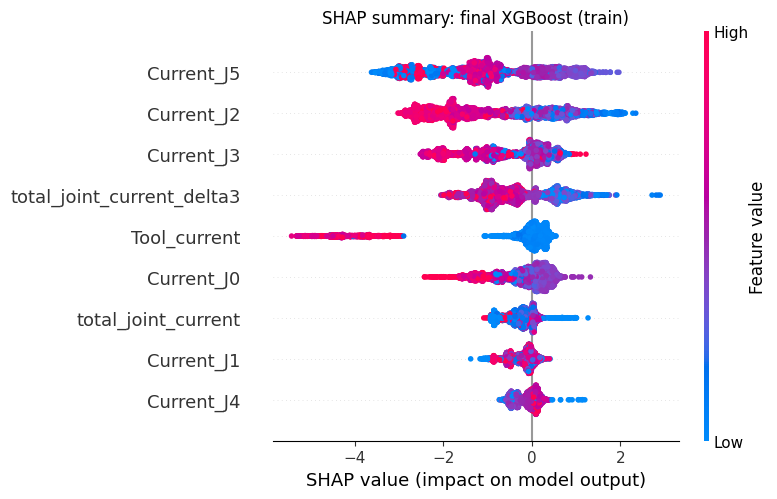

Current_J5                    1.347
Current_J2                    1.305
Current_J3                    0.769
total_joint_current_delta3    0.760
Tool_current                  0.753
Current_J0                    0.443
total_joint_current           0.302
Current_J1                    0.244
Current_J4                    0.212
dtype: float32

In [16]:
fitted_train = clone(final_pipeline).fit(X_train[FINAL_FEATURES], y_train)
feature_names = [c for c in FINAL_FEATURES if c not in BINARY_COLS] + [c for c in FINAL_FEATURES if c in BINARY_COLS]
X_scaled = fitted_train.named_steps["preprocessing"].transform(X_train[FINAL_FEATURES])

explainer = shap.TreeExplainer(fitted_train.named_steps["classifier"])
shap_values = explainer.shap_values(X_scaled)
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)

plt.figure()
shap.summary_plot(shap_values, X_scaled, feature_names=feature_names, show=False)
plt.title("SHAP summary: final XGBoost (train)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig07_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

mean_abs_shap.round(3)

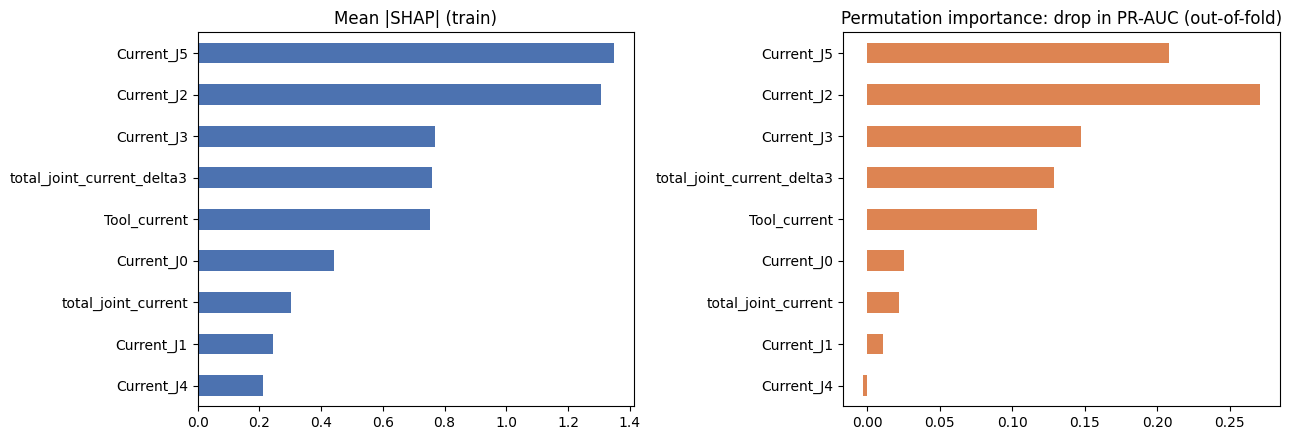

,mean |SHAP|,permutation (PR-AUC drop)
Current_J0,0.4432,0.0256
Current_J1,0.2440,0.0107
Current_J2,1.3054,0.2710
Current_J3,0.7694,0.1472
Current_J4,0.2119,-0.0029
Current_J5,1.3473,0.2082
Tool_current,0.7529,0.1169
total_joint_current,0.3020,0.0219
total_joint_current_delta3,0.7603,0.1290


In [17]:
perm_importance = oof_permutation_importance(final_pipeline, FINAL_FEATURES)

order = mean_abs_shap.index
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mean_abs_shap[order][::-1].plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("Mean |SHAP| (train)")
perm_importance[order][::-1].plot.barh(ax=axes[1], color="#dd8452")
axes[1].set_title("Permutation importance: drop in PR-AUC (out-of-fold)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"mean |SHAP|": mean_abs_shap, "permutation (PR-AUC drop)": perm_importance}).round(4)

### 6b. What does `total_joint_current_delta3` actually capture?

It is the second most important feature by SHAP and third by permutation importance, and it is the reason the API needs history. Notebook 04 originally introduced it as a way of capturing the rising current seen before a stop in notebook 03 (both notebooks have since been revised in light of this analysis). Two checks on **train**, to see whether that is what the model is using:

1. **Direction:** does a rise push the prediction toward a stop or away from it? (SHAP value against the feature value, and the stop rate by delta3 bin.)
2. **A fair comparison for the rise before a stop.** Every cycle starts with the same current wave, and stops tend to start early in a cycle, so a rise "before a stop" can simply be the normal start of a cycle. The check compares the rows just before each stop with **normal rows at the same position inside their cycle**.

In [18]:
stop = (y_train == 1).to_numpy()
cyc = train_df["cycle"].to_numpy()
pos = train_df.groupby("cycle").cumcount().to_numpy()          # 0-based row position inside its cycle
d3 = train_df["total_joint_current_delta3"].to_numpy()          # NaN for the first 3 rows of every cycle
episodes = find_runs(stop, cyc)

# 1. Direction of the effect.
j = feature_names.index("total_joint_current_delta3")
defined = ~np.isnan(d3)
print("Spearman correlation between delta3 and its SHAP value: "
      f"{spearmanr(d3[defined], shap_values[defined, j]).statistic:.2f}  (negative: a rise pushes away from 'stop')\n")
by_bin = (
    pd.DataFrame({"delta3 bin": pd.cut(pd.Series(d3[defined]), [-np.inf, -5, -2, 0, 2, 5, np.inf]).to_numpy(),
                  "stop": stop[defined], "SHAP": shap_values[defined, j]})
    .groupby("delta3 bin", observed=True).agg(rows=("stop", "size"), stop_rate=("stop", "mean"), mean_SHAP=("SHAP", "mean"))
)
print(f"Stop rate by delta3 bin (rows with delta3 defined; overall {stop[defined].mean():.3f}):")
print(by_bin.round(3).to_string())

# 2. Where do stops start inside a cycle, and is the rise before a stop more than the normal cycle-start wave?
onset_pos = np.array([pos[s] for s, _ in episodes])
print(f"\n{len(episodes)} stop episodes; first stop row sits at cycle position median {np.median(onset_pos):.0f} "
      f"(0-based), {int((onset_pos < 6).sum())} of {len(episodes)} within the first 6 rows of a cycle.")

normal = pd.DataFrame({"pos": pos, "d3": d3})[~stop]
print("\nDelta3 of NORMAL rows by cycle position (every cycle starts with the same current wave):")
print(normal[normal["pos"].between(3, 9)].groupby("pos")["d3"]
      .agg(rows="size", median="median", pct_rising=lambda v: 100 * (v > 0).mean()).round(2).T.to_string())

rows = {}
for k in (3, 2, 1):
    idx = [s - k for s, _ in episodes
           if s - k >= 0 and cyc[s - k] == cyc[s] and not stop[s - k] and pos[s - k] >= 3]
    before = d3[idx]
    same_pos = np.concatenate([normal.loc[normal["pos"] == pos[i], "d3"].dropna().to_numpy() for i in idx])
    rows[f"{k} row(s) before a stop"] = {
        "episodes": len(idx),
        "median delta3": np.median(before), "% rising": 100 * (before > 0).mean(),
        "same-position normal rows: median": np.median(same_pos), "same-position: % rising": 100 * (same_pos > 0).mean(),
    }
print("\nRows just before a stop start, against normal rows at the same cycle position:")
print(pd.DataFrame(rows).T.round(2).to_string())

later_stop = [t for s, e in episodes for t in range(s + 1, e + 1)]
print("\nDelta3 at the first stop row / later stop rows / normal rows (median, % rising):")
for label, idx in {"first stop row": [s for s, _ in episodes], "later stop rows": later_stop,
                   "normal rows": np.where(~stop)[0]}.items():
    v = d3[idx]
    v = v[~np.isnan(v)]
    print(f"  {label:16s} n={len(v):4d}  median {np.median(v):+.2f}  rising {100 * (v > 0).mean():.0f}%")

Spearman correlation between delta3 and its SHAP value: -0.69  (negative: a rise pushes away from 'stop')

Stop rate by delta3 bin (rows with delta3 defined; overall 0.035):
              rows  stop_rate  mean_SHAP
delta3 bin                              
(-inf, -5.0]   301      0.030      0.675
(-5.0, -2.0]   650      0.063      0.775
(-2.0, 0.0]   1751      0.031     -0.291
(0.0, 2.0]    1410      0.032     -0.622
(2.0, 5.0]     556      0.031     -0.605
(5.0, inf]     224      0.018     -1.223

57 stop episodes; first stop row sits at cycle position median 5 (0-based), 39 of 57 within the first 6 rows of a cycle.

Delta3 of NORMAL rows by cycle position (every cycle starts with the same current wave):
pos              3       4       5       6       7       8       9
rows        181.00  171.00  162.00  166.00  177.00  185.00  186.00
median        4.07    0.91   -3.55   -4.68   -2.35    0.52    1.12
pct_rising   97.24   65.50    5.56    6.02   11.30   61.62   83.87

Rows just before 

## 7. Decision threshold

**Rule: the threshold that maximises F1 on out-of-fold predictions from train.** It is computed, not hand-picked, and the test set is not involved. The other policies are shown so the cost of moving away from it is visible.

Two views of each policy. Row level (every reading is one prediction): recall, precision, and `false alarms per true stop row`. Event level, which is what an operator experiences: a *stop episode* is a run of consecutive stop rows, an *alarm run* is a run of consecutive flagged rows, and a *false-alarm run* is one that neither overlaps a stop nor starts within 5 rows before one (a flag just before a stop is an early warning, not a false alarm). Rows are about one second apart.

In [19]:
oof_final = cross_val_predict(final_pipeline, X_train[FINAL_FEATURES], y_train, groups=groups, cv=cv,
                              method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_final)
prec, rec = prec[:-1], rec[:-1]
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)


def evaluate_at(t):
    pred = oof_final >= t
    pos = (y_train == 1).to_numpy()
    tp, fp, fn = int((pred & pos).sum()), int((pred & ~pos).sum()), int((~pred & pos).sum())
    return {"threshold": round(float(t), 3), "recall": tp / (tp + fn), "precision": tp / (tp + fp),
            "F1": 2 * tp / (2 * tp + fp + fn), "false alarms per true stop row": fp / tp,
            "rows flagged (%)": 100 * pred.mean()}


policies = {"default 0.5": 0.5, "best F1": thr[np.argmax(f1_curve)]}
for target in (0.70, 0.75, 0.80, 0.85, 0.90):
    ok = rec >= target
    policies[f"recall >= {target:.2f}"] = thr[np.where(ok)[0][np.argmax(prec[ok])]]

pd.DataFrame({name: evaluate_at(t) for name, t in policies.items()}).T.round(3)

,threshold,recall,precision,F1,false alarms per true stop row,rows flagged (%)
default 0.5,0.500,0.747,0.376,0.500,1.661,6.181
best F1,0.657,0.676,0.431,0.526,1.322,4.883
recall >= 0.70,0.603,0.706,0.404,0.514,1.475,5.432
recall >= 0.75,0.482,0.753,0.369,0.495,1.711,6.346
recall >= 0.80,0.390,0.800,0.353,0.490,1.831,7.041
recall >= 0.85,0.155,0.853,0.239,0.373,3.186,11.101
recall >= 0.90,0.063,0.900,0.152,0.260,5.569,18.380


In [20]:
cycle_arr = train_df["cycle"].to_numpy()
episode_table = pd.DataFrame(
    {name: episode_metrics(y_train, oof_final >= t, cycle_arr) for name, t in policies.items()}
).T
episode_table.round(1)

,stop episodes,caught during (%),onset row flagged (%),warned in 5 rows before (%),caught or warned (%),alarm runs,false-alarm runs,false-alarm runs per hour
default 0.5,57.0,94.7,70.2,22.8,96.5,121.0,55.0,36.2
best F1,57.0,94.7,59.6,19.3,96.5,104.0,40.0,26.3
recall >= 0.70,57.0,94.7,64.9,21.1,96.5,111.0,46.0,30.3
recall >= 0.75,57.0,94.7,71.9,24.6,96.5,124.0,57.0,37.5
recall >= 0.80,57.0,94.7,77.2,26.3,96.5,134.0,70.0,46.1
recall >= 0.85,57.0,98.2,87.7,35.1,98.2,285.0,215.0,141.6
recall >= 0.90,57.0,100.0,91.2,56.1,100.0,534.0,454.0,298.9


In [21]:
FINAL_THRESHOLD = float(policies["best F1"])
print(f"Final threshold (rule: maximise F1 on out-of-fold train predictions): {FINAL_THRESHOLD:.4f}")

Final threshold (rule: maximise F1 on out-of-fold train predictions): 0.6565


## 8. Test-set evaluation (run once)

The held-out test split is the last 20% of cycles by time (48 cycles), so this asks how the model does on **later** cycles it has never seen. Model, features, hyperparameters and threshold were all fixed above from cross-validation on train. **Nothing may be changed after these numbers have been seen.** The stop rate is higher in the test split than in train, so PR-AUC is not directly comparable with the cross-validation figures: the no-skill PR-AUC on each split equals its stop rate.

In [22]:
# ONE-SHOT TEST EVALUATION. Model, features, hyperparameters and threshold are fixed; do not alter them after looking.
assert FINAL_THRESHOLD is not None

test_df = pd.read_parquet(PROCESSED_DATA_DIR / "test.parquet")
X_test, y_test = test_df[FINAL_FEATURES], test_df["Robot_ProtectiveStop"]

final_fitted = clone(final_pipeline).fit(X_train[FINAL_FEATURES], y_train)
proba_test = final_fitted.predict_proba(X_test)[:, 1]
pred_test = proba_test >= FINAL_THRESHOLD

tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
test_metrics = {
    "PR-AUC": average_precision_score(y_test, proba_test),
    "ROC-AUC": roc_auc_score(y_test, proba_test),
    "recall": recall_score(y_test, pred_test),
    "precision": precision_score(y_test, pred_test),
    "F1": f1_score(y_test, pred_test),
    "balanced accuracy": balanced_accuracy_score(y_test, pred_test),
}
print(f"Test rows: {len(y_test)}, stop rows: {int(y_test.sum())} ({100 * y_test.mean():.2f}% of rows; "
      f"train: {100 * y_train.mean():.2f}%)")
print(f"No-skill PR-AUC = stop rate: test {y_test.mean():.3f}, train {y_train.mean():.3f}")
print(f"Threshold {FINAL_THRESHOLD:.3f}: TP={tp}  FP={fp}  FN={fn}  TN={tn}")
pd.Series(test_metrics).round(3)

Test rows: 1887, stop rows: 108 (5.72% of rows; train: 3.11%)
No-skill PR-AUC = stop rate: test 0.057, train 0.031
Threshold 0.657: TP=70  FP=65  FN=38  TN=1714


PR-AUC               0.479
ROC-AUC              0.911
recall               0.648
precision            0.519
F1                   0.576
balanced accuracy    0.806
dtype: float64

In [23]:
test_cycle = test_df["cycle"].to_numpy()
test_episodes = episode_metrics(y_test, pred_test, test_cycle)
print(f"Event level on the test split ({len(y_test) / 3600:.2f} hours of readings):")
print(pd.Series(test_episodes).round(1).to_string())

# Train (out-of-fold) vs test at the same threshold, row level.
train_at_t = evaluate_at(FINAL_THRESHOLD)
compare = pd.DataFrame({
    "train (out-of-fold)": {k: train_at_t[k] for k in ("recall", "precision", "F1")},
    "test (later cycles)": {"recall": test_metrics["recall"], "precision": test_metrics["precision"],
                            "F1": test_metrics["F1"]},
})
print()
print(compare.round(3).to_string())

Event level on the test split (0.52 hours of readings):
stop episodes                  51.0
caught during (%)              84.3
onset row flagged (%)          51.0
warned in 5 rows before (%)    15.7
caught or warned (%)           86.3
alarm runs                     59.0
false-alarm runs               14.0
false-alarm runs per hour      26.7

           train (out-of-fold)  test (later cycles)
recall                   0.676                0.648
precision                0.431                0.519
F1                       0.526                0.576


## 9. Save the final pipeline

One artifact for the backend: the fitted preprocessing + classifier pipeline, the decision threshold, and the exact list of input features the pipeline expects. The model is fit on the **train** split only, so the saved model is exactly the one evaluated in section 8. The backend must build the two engineered features with `src.features.add_engineered_features` before selecting `features`.

In [24]:
FINAL_BUNDLE = {"pipeline": final_fitted, "threshold": FINAL_THRESHOLD, "features": FINAL_FEATURES}

MODELS_DIR.mkdir(exist_ok=True)
artifact_path = MODELS_DIR / "final_pipeline.joblib"
joblib.dump(FINAL_BUNDLE, artifact_path)

# Reload and confirm the saved model reproduces the evaluated predictions exactly.
reloaded = joblib.load(artifact_path)
np.testing.assert_allclose(reloaded["pipeline"].predict_proba(X_test)[:, 1], proba_test)
assert reloaded["features"] == FINAL_FEATURES and reloaded["threshold"] == FINAL_THRESHOLD
print(f"Saved {artifact_path.name}: {artifact_path.stat().st_size / 1024:.0f} KB, "
      f"threshold {reloaded['threshold']:.4f}, {len(reloaded['features'])} features")

Saved final_pipeline.joblib: 357 KB, threshold 0.6565, 9 features


## 10. Early-warning ablation (exploratory, train only)

The plan lists "detection vs early warning" as an ablation. Detection flags a stop on the row where it happens; early warning would flag a stop *before* it starts. This section asks whether the data supports that, using **only the training split** (the test set is not touched).

Target: on rows that are not already in a stop, "a stop starts within the next *k* rows of the same cycle" (*k* = 3, 5, 10; about one row per second). Five feature sets are compared: position in the cycle alone (a pure phase prior), the final 9 features, the 9 plus position, a richer 6-reading history, and that plus position. Model settings are fixed and untuned (200 trees, depth 3), so read the results as directional. The event-level columns use each feature set's own best-F1 threshold, so they are not directly comparable across rows.

In [25]:
ew_df = train_df.reset_index(drop=True).copy()
ew_cycle = ew_df["cycle"].to_numpy()
ew_stop = (ew_df["Robot_ProtectiveStop"] == 1).to_numpy()
ew_df["cycle_pos"] = ew_df.groupby("cycle").cumcount()

JOINT_CURRENTS = [f"Current_J{i}" for i in range(6)]
for c in JOINT_CURRENTS:
    ew_df[f"{c}_d3"] = ew_df.groupby("cycle")[c].diff(3)
ew_df["total_d1"] = ew_df.groupby("cycle")["total_joint_current"].diff(1)
ew_df["total_std5"] = ew_df.groupby("cycle")["total_joint_current"].transform(lambda s: s.rolling(5, min_periods=3).std())
RICH = FINAL_FEATURES + [f"{c}_d3" for c in JOINT_CURRENTS] + ["total_d1", "total_std5"]
EW_SETS = {
    "position in cycle only": ["cycle_pos"],
    "final 9 features": FINAL_FEATURES,
    "9 features + position": FINAL_FEATURES + ["cycle_pos"],
    "richer history (6 readings)": RICH,
    "richer history + position": RICH + ["cycle_pos"],
}


def stop_within_next(k):
    """True where a stop row occurs within the next k rows of the same cycle."""
    out = np.zeros(len(ew_df), bool)
    for j in range(1, k + 1):
        ahead = np.zeros(len(ew_df), bool)
        ahead[:-j] = ew_stop[j:] & (ew_cycle[j:] == ew_cycle[:-j])
        out |= ahead
    return out


def make_ew_pipeline(features):
    return Pipeline([
        ("preprocessing", build_preprocessing_pipeline(features, [])),
        ("classifier", xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE,
                                         eval_metric="logloss", n_jobs=4)),
    ])


scored = np.where(~ew_stop)[0]  # rows already in a stop are a detection question, not a warning question
ew_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ew_rows = []
for k in (3, 5, 10):
    y_k = stop_within_next(k)[scored]
    for name, feats in EW_SETS.items():
        Xk = ew_df.loc[scored, feats].reset_index(drop=True)
        oof_k, fold_ap = np.zeros(len(scored)), []
        for tr, va in ew_cv.split(Xk, y_k, ew_cycle[scored]):
            m = make_ew_pipeline(feats)
            m.set_params(classifier__scale_pos_weight=(1 - y_k[tr].mean()) / y_k[tr].mean())
            m.fit(Xk.iloc[tr], y_k[tr])
            oof_k[va] = m.predict_proba(Xk.iloc[va])[:, 1]
            fold_ap.append(average_precision_score(y_k[va], oof_k[va]))
        p_k, r_k, t_k = precision_recall_curve(y_k, oof_k)
        f1_k = 2 * p_k[:-1] * r_k[:-1] / (p_k[:-1] + r_k[:-1] + 1e-12)
        alarm = np.zeros(len(ew_df), bool)
        alarm[scored] = oof_k >= t_k[np.argmax(f1_k)]
        em = episode_metrics(ew_stop.astype(int), alarm, ew_cycle, early_horizon=k)
        ew_rows.append({"horizon k (rows)": k, "features": name, "no-skill PR-AUC": y_k.mean(),
                        "PR-AUC": np.mean(fold_ap), "PR-AUC std": np.std(fold_ap), "best F1": f1_k.max(),
                        "episodes warned (%)": em[f"warned in {k} rows before (%)"],
                        "false-alarm runs/hour": em["false-alarm runs per hour"]})
pd.DataFrame(ew_rows).set_index(["horizon k (rows)", "features"]).round(3)

no-skill PR-AUC  PR-AUC  PR-AUC std  best F1  episodes warned (%)  false-alarm runs/hour
horizon k (rows) features                                                                                                             
3                position in cycle only                 0.031   0.143       0.038    0.255               71.930                100.073
                 final 9 features                       0.031   0.177       0.053    0.247               71.930                143.526
                 9 features + position                  0.031   0.188       0.019    0.266               59.649                 84.931
                 richer history (6 readings)            0.031   0.189       0.027    0.273               75.439                111.266
                 richer history + position              0.031   0.215       0.056    0.264               73.684                140.234
5                position in cycle only                 0.045   0.164       0.045    0.299               71.930                101.390
                 final 9 features                       0.045   0.210       0.062    0.287               77.193                154.718
                 9 features + position                  0.045   0.224       0.054    0.310               75.439                127.725
                 richer history (6 readings)            0.045   0.209       0.042    0.306               80.702                142.209
                 richer history + position              0.045   0.214       0.047    0.308               77.193                140.892
10               position in cycle only                 0.054   0.158       0.018    0.287               77.193                102.048
                 final 9 features                       0.054   0.210       0.041    0.283               87.719                165.252
                 9 features + position                  0.054   0.210       0.035    0.305               85.965                146.159
                 richer history (6 readings)            0.054   0.213       0.034    0.306               87.719                171.836
                 richer history + position              0.054   0.206       0.039    0.309               82.456                140.234

## Decision log

### Decision (Bandara): final model is XGBoost, a close call with Random Forest
- **Evidence:** 5-fold grouped CV on the final 9 features, with the notebook-06 hyperparameters held fixed for every model: XGBoost PR-AUC 0.476 (std 0.041), Random Forest 0.446 (0.081), SVM 0.404 (0.059), Logistic Regression 0.155 (0.037). XGBoost is ahead of Random Forest in only 2 of 5 folds (mean gap +0.030), and Random Forest is slightly ahead in time-forward validation (0.393 vs 0.385), so on PR-AUC the two are a tie. On the 16 features (section 1) it is the same picture: ahead in 3 of 5 folds (+0.035), inside Random Forest's fold std of 0.111. At matched operating points (16 features, out-of-fold) the two trade places: precision at recall >= 0.70 is 0.410 (XGBoost) vs 0.377 (Random Forest), 0.325 vs 0.322 at recall >= 0.80, and 0.109 vs 0.147 at recall >= 0.90. SVM is clearly behind at matched recall (precision 0.166 at recall >= 0.80); its high recall at the default threshold comes with low precision (0.217), not better ranking. Logistic Regression cannot rank this problem (PR-AUC 0.155).
- **Alternative considered:** Random Forest, which is a defensible choice.
- **Why XGBoost:** the tie on PR-AUC is broken by the other criteria the plan names, not by a claim of superiority: about half the fold-to-fold spread (std 0.041 vs 0.081 on the final set), about 3x faster single-row inference (median 3.5 ms vs 10.3 ms per call, measured on the 16-feature pipelines the way the API calls them, section 1), and a default threshold that already behaves sensibly (F1 0.500 vs 0.457 at 0.5). The report should describe the two models as close.
- **Correction:** notebook 06 called XGBoost's lead over Random Forest "a clear margin". That holds against Logistic Regression and SVM, not against Random Forest. The notebook-06 entry has been corrected.

### Decision (Bandara): the API takes a reading plus history, and keeps the trend feature
- **Evidence:** `total_joint_current_delta3` needs the reading 3 steps back. Trained with it but served without it (what a single-reading API would do), XGBoost loses 0.09 PR-AUC (0.473 to 0.379) and about a quarter of its recall (0.689 to 0.528), which is worse than never using the feature (0.414 on 15 features). With history the feature is worth +0.06 PR-AUC (0.473 vs 0.414, ahead in 5 of 5 folds).
- **Alternative considered:** one reading per request with the trend feature dropped (PR-AUC 0.414, no API or UI change).
- **Why rejected:** the version with history scores about 14% higher. The extra input is small once the temperatures are dropped: the current reading plus the six joint currents from 3 readings earlier (readings t-1 and t-2 are not used by any feature).
- **Guard against train/serve skew:** the engineered features live in `src/features.py`. Section 3 asserts that this code reproduces the stored training columns exactly (whole train split) and that 300 random 4-row windows give the same delta3 through the serving path. Assumptions the API cannot verify: the readings are consecutive and from the same cycle.

### Decision (Bandara): drop the six temperatures and grip_lost (9 features remain)
- **Evidence:**
  - *They contribute nothing.* Out-of-fold permutation importance on the 16-feature model: the temperatures range from -0.013 to +0.007 and three of the six (T0, J1, J5) are negative, meaning shuffling them slightly helps; grip_lost is 0.000. Only 3 of its 243 True rows overlap a stop.
  - *Dropping them costs no accuracy and helps on later cycles.* Grouped CV PR-AUC 0.473 to 0.476 (std 0.074 to 0.041). Time-forward validation (train on earlier cycles, score on later ones) improves in all 4 blocks: mean 0.347 to 0.385. The blocks hold only 31 to 47 stop rows each, so read this as direction, not decimals.
  - *Temperature in this data is a clock.* Its Spearman correlation with elapsed time is 0.79 to 1.00 at every joint. It climbs during the first ~50 minutes of readings and is nearly flat after the break, at -0.6 to +1.5 C per hour (`fig07_temperature_vs_time.png`).
  - *Once time is controlled, stops are not hotter.* The median temperature at stop rows minus normal rows is 0.0 C at every joint in the after-the-break segment (95 stop rows) and about +1 C in the before-the-break warm-up segment (75 stop rows). During that warm-up the temperatures rise about 8 to 12 C per hour, so a 1 C difference amounts to roughly 6 minutes of warm-up. That fits temperature reflecting when a row was recorded, not stops being hotter.
- **Alternative considered:** keep all 16 features, as notebooks 04 to 06 did.
- **Why rejected:** no accuracy gained, worse on later cycles in every time-forward block, six extra inputs, and a model leaning on a variable that is really the time of day would break on a day with a different warm-up curve.
- **If asked about overheating:** we are not claiming heat cannot cause protective stops on a real robot. In this dataset temperature carried no usable signal for these stops, and the model that used it was worse on later cycles. Motor current is what tracks the stops here (importance ranking in section 6).
- **Limits:** one robot and about 2 hours of readings (spread over a 7-hour day), temperatures between 28 and 45 C. A slow thermal effect building over weeks would not appear in this data, and this analysis cannot rule it out. "Temperature acts as a time-of-day shortcut" is the explanation that fits the evidence (a near-perfect clock, and removing it helped on later cycles), but the mechanism is inferred, not proven. Worth re-testing with longer recordings.
- **Consequence:** the eligible-feature list from notebook 03, which allowed temperatures, is narrowed to 9 features in the deployed model.

### Observation (Bandara): what the trend feature captures, and what it does not (section 6b)
- **Evidence:**
  - *Direction.* Low delta3 pushes toward "stop", high pushes away (Spearman -0.69 between the value and its SHAP value). The stop rate is highest after a moderate fall (6.3% for delta3 between -5 and -2, against 3.5% overall) and lowest after a big rise (1.8% above +5).
  - *Stops cluster at the start of a cycle.* The first stop row sits at a median of row 5 of its cycle (0-based), and 39 of 57 episodes start within the first 6 rows. Every normal cycle has the same current wave there: median delta3 is +4.1 at row 3 (97% rising), -3.6 at row 5 (6% rising) and -4.7 at row 6. So delta3 also tells the model where in the cycle a row sits.
  - *The rise before a stop mostly matches that wave.* One row before onset the median delta3 is +1.16 (76% rising) against +1.30 (70%) for normal rows at the same cycle positions, and two rows before it is +3.62 against +2.74. Only three rows before onset stands out (+2.50, 93% rising, against +0.09, 53% for same-position normal rows), and that is 15 episodes, because most stops are too early in the cycle for delta3 to exist three rows back.
  - *At and after onset.* Median delta3 is -0.23 at the first stop row, -0.77 in later stop rows (63% falling) and -0.10 for normal rows.
- **Interpretation:** delta3 is mostly a cycle-phase and trend signal. Stops concentrate where the current is falling after the initial rise, and the model uses a fall as a sign of a stop, not a rise as a warning. Notebooks 03 and 04 originally described the rise in current before a stop as a possible precursor, and this feature as capturing it (both now reworded after the same-cycle-position control in notebook 03, which finds the same thing). That is not what the evidence supports: the pre-stop rise is largely the ordinary cycle-start wave, with a possible real rise only for the few mid-cycle stops (n = 15, not tested further). This is consistent with how little advance warning the model gives (19.3% of train episodes and 15.7% of test episodes flagged in the 5 rows before onset).
- **Implication for the framing decision:** this analysis does not show that delta3 gives early warning. An early-warning target was then tested directly, including a cycle-position feature (section 10): it is above chance but not practical, so detection remains the recommended framing.
- **Checks not done:** delta3 was checked with grouped CV only (ahead of the 15-feature model in 5 of 5 folds), not with time-forward validation, and the mid-cycle rise has not been tested beyond the 15 episodes above.

### Decision (Bandara): alert threshold is the F1-maximising cut-off on out-of-fold train predictions (0.657)
- **Rule and value:** maximise F1 on out-of-fold predictions from train. On the final 9-feature model this gives 0.657, which is computed from the final model's own predictions, not carried over from an earlier feature set. Out-of-fold at 0.657: recall 0.676, precision 0.431, F1 0.526; 94.7% of stop episodes have at least one flagged row, 59.6% are flagged at their first row, and there are about 26 false-alarm runs per hour.
- **Alternatives (train, out-of-fold, event level):** default 0.5: 94.7% caught, 70.2% flagged at the first row, 36 false-alarm runs per hour. Row recall >= 0.80 (threshold 0.390): the same 94.7% caught, 77.2% flagged at the first row, 46 false-alarm runs per hour. Row recall >= 0.90 (threshold 0.063): 100% caught, 91% at the first row, but 299 false-alarm runs per hour, about one every 12 seconds.
- **Why F1:** lowering the threshold down to row recall 0.80 does not catch more stop episodes (94.7% throughout); it flags them sooner and at more cost. Going from 0.657 to recall 0.80 buys +18 points flagged at the first row for 75% more false alarms. Row-level recall overstates the value because a 12-row stop counts 12 times. A safer-side threshold is a legitimate choice for the team; it is stored in the artifact, so changing it needs no retraining. Any change made after seeing the test result must be reported as post-hoc.
- **Recommendation for the 29 Sep meeting:** keep 0.6565 as the Alert and 0.39 as a Watch tier (the API already shows both). Going from 0.657 to recall 0.85 (threshold 0.155) catches 2 more of the 57 train episodes (98.2% vs 94.7%) for about 175 more false-alarm runs; recall 0.90 raises a false alarm every 12 seconds. A missed flag is not a hazard, because the robot's own certified safety system stops it regardless, while false alarms cost operator trust. That weighting is a judgement, not a result, so it is the team's decision.

### Result (Bandara): one-shot test evaluation on later cycles
- **Fixed before the test:** model (XGBoost), 9 features, notebook-06 hyperparameters, threshold 0.657 (rule above). Nothing was changed after these numbers were seen.
- **Row level:** PR-AUC 0.479 (no-skill 0.057), ROC-AUC 0.911, recall 0.648, precision 0.519, F1 0.576, balanced accuracy 0.806 (TP 70, FP 65, FN 38, TN 1714 over 1,887 rows).
- **Event level (51 stop episodes, 0.52 hours of readings):** 84.3% of episodes had at least one flagged row (43 of 51), 51.0% were flagged at their first row, 15.7% were flagged in the 5 rows before, and there were 14 false-alarm runs (26.7 per hour, matching train's 26.3).
- **Against cross-validation:** row-level recall is close (0.648 vs 0.676 out-of-fold). Precision is higher (0.519 vs 0.431) because the stop rate nearly doubled (5.7% vs 3.1%), which raises precision and also PR-AUC's no-skill floor, so PR-AUC is not directly comparable. The event-level catch rate is lower than cross-validation suggested: 84.3% against 94.7%. Test episodes are shorter (2.1 stop rows each against 3.0 in train), and a shorter episode gives the model fewer chances to flag at least one row, which is a likely part of the drop at similar row-level recall. With only 51 episodes the 84.3% is imprecise (a 95% Wilson interval is roughly 72% to 92%), so the gap to 94.7% may partly be noise.

### Exploratory (Bandara): early warning is statistically above chance but not practical with this data (section 10)
- **Evidence:** train only, grouped CV, fixed untuned XGBoost. At k = 5 rows (no-skill PR-AUC 0.045) PR-AUC is 0.164 for position-in-cycle alone, 0.210 for the final 9 features, 0.224 with position added and 0.209-0.214 with richer history (fold std 0.04-0.06). k = 3 and k = 10 tell the same story (0.14-0.22 and 0.16-0.21 against no-skill 0.031 and 0.054). Warning 60-88% of stops needs about 85-170 false-alarm runs per hour (best F1 0.25-0.31), against 26 per hour for the detection model.
- **Reading:** about 3-7x chance, but most of it is "stops happen at the start of a cycle" (position alone gets 0.14-0.16); the currents add about 0.03-0.05, roughly one fold std, and richer history does not help.
- **Recommendation (team decision, 29 Sep):** keep detection as the delivered framing and report early warning as the ablation. Do not claim the tool gives early warning. Caveats: exploratory, untuned, one seed, 57 training episodes.
- **Alternative considered:** deliver an early-warning model. **Why not:** the false-alarm cost is several times higher for a warning that is mostly a prior about the cycle phase.

### Limitations
- One robot and about 2 hours of readings spread over one day. The split is chronological, so the test set is the last 20% of cycles, when stops were also more frequent.
- The test set holds 51 stop episodes, so event-level rates carry wide uncertainty.
- The model mainly detects a stop as it begins or while it is under way. It gives little advance warning (15.7% of test episodes flagged in the 5 rows before), and the trend feature does not change that (see the observation above).
- Stops concentrate at the start of a cycle, and the model's trend feature encodes cycle position, so it may not transfer to a robot running a different program.
- The API assumes the readings it is given are consecutive and from the same cycle, and cannot check this.
- About 26 false-alarm runs per hour at the chosen threshold would be a lot of alerts for an operator. This is a decision-support estimate, not a certified safety system.
- Hyperparameters were tuned on the 16-feature set and reused for the 9-feature set, where they performed at least as well.
